# 00 - Environment Setup and Dataset Overview

This notebook now includes visible embedded overview plots plus runnable setup and audit code.

In [1]:
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
import pandas as pd
import matplotlib.pyplot as plt
DATA_DIR = Path.cwd().parent / 'data' if (Path.cwd().parent / 'data').exists() else Path.cwd() / 'data'
print('Libraries imported successfully.')
print('Data path resolved.')

Libraries imported successfully.
Data path resolved.


In [2]:
student_scores = pd.read_csv(DATA_DIR / 'simple_linear_student_scores.csv')
marketing_sales = pd.read_csv(DATA_DIR / 'multiple_regression_marketing_sales.csv')
pd.DataFrame({'dataset':['simple_linear_student_scores.csv','multiple_regression_marketing_sales.csv'], 'rows':[len(student_scores), len(marketing_sales)], 'columns':[student_scores.shape[1], marketing_sales.shape[1]], 'target':['exam_score','sales_k_units']})

                                   dataset  rows  columns          target
0        simple_linear_student_scores.csv    60        4      exam_score
1  multiple_regression_marketing_sales.csv   120        8  sales_k_units

## Target distributions

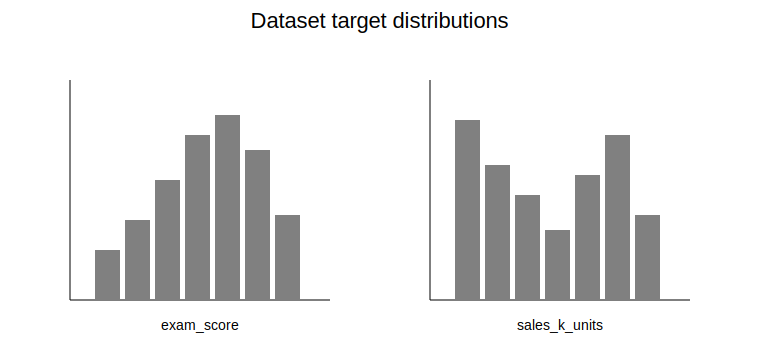

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(student_scores['exam_score'], bins=12, edgecolor='black')
axes[0].set_title('Distribution of exam_score')
axes[1].hist(marketing_sales['sales_k_units'], bins=14, edgecolor='black')
axes[1].set_title('Distribution of sales_k_units')
plt.tight_layout()
plt.show()

## Correlation heatmap

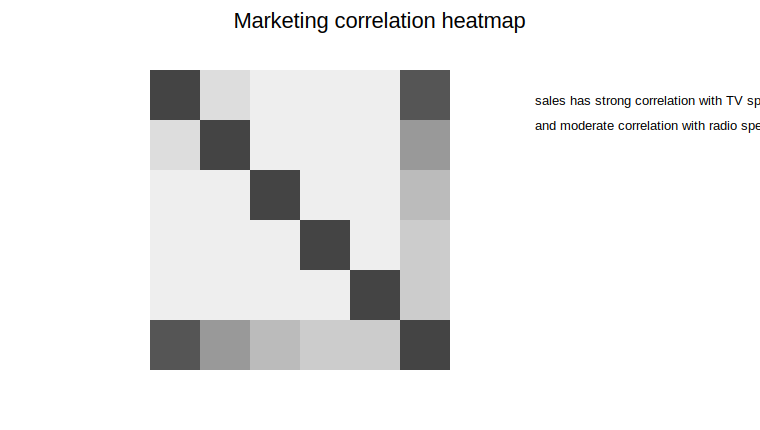

                    tv_spend_k  radio_spend_k  social_spend_k  price_index  competitor_spend_k  sales_k_units
tv_spend_k                1.00          -0.08            0.00         0.01               -0.03           0.84
radio_spend_k            -0.08           1.00           -0.06         0.00               -0.01           0.33
social_spend_k            0.00          -0.06            1.00         0.00                0.08           0.16
price_index               0.01           0.00            0.00         1.00               -0.02          -0.14
competitor_spend_k       -0.03          -0.01            0.08        -0.02                1.00          -0.13
sales_k_units             0.84           0.33            0.16        -0.14               -0.13           1.00

In [4]:
numeric_cols = ['tv_spend_k','radio_spend_k','social_spend_k','price_index','competitor_spend_k','sales_k_units']
corr = marketing_sales[numeric_cols].corr().round(2)
fig, ax = plt.subplots(figsize=(8,6))
ax.imshow(corr, vmin=-1, vmax=1)
plt.show()
corr

## Notebook map
- `01_simple_linear_regression_end_to_end.ipynb`: simple regression
- `02_multiple_linear_regression_end_to_end.ipynb`: multiple regression
- `03_diagnostics_regularization_and_interpretability.ipynb`: diagnostics and regularization